<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [1]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [2]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows of the data to understand its structure
df.head()


Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  7.21MB/s    in 22s     

2026-08-30 12:43:30 (6.79 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


In [37]:
# First let's update our Age column for shorter categories
age_mapping = {
    "Under 18 years old": "<18",
    "18-24 years old": "18-24",
    "25-34 years old": "25-34",
    "35-44 years old": "35-44",
    "45-54 years old": "45-54",
    "55-64 years old": "55-64",
    "65 years or older": "65+"
}

df["Age"] = df["Age"].replace(age_mapping)

In [38]:
# Let's prepare our dataframe
bubble_df = df[
    ["Age", "SOPartFreq", "JobSat"]
].copy()

bubble_df["JobSat"] = pd.to_numeric(
    bubble_df["JobSat"],
    errors="coerce"
)

bubble_df = bubble_df.dropna(
    subset=["Age", "SOPartFreq", "JobSat"]
)

In [39]:
# Let's check SOPartFreq categories
bubble_df["SOPartFreq"].value_counts()

SOPartFreq
Less than once per month or monthly                   12948
I have never participated in Q&A on Stack Overflow     4833
A few times per month or weekly                        3493
A few times per week                                   1312
Daily or almost daily                                   554
Multiple times per day                                  248
Name: count, dtype: int64

In [16]:
# Let's agragate our data
bubble_stats = (
    bubble_df
    .groupby(["Age", "SOPartFreq"])
    .agg(
        AvgJobSat=("JobSat", "mean"),
        Respondents=("JobSat", "count")
    )
    .reset_index()
)

bubble_stats

,Age,SOPartFreq,AvgJobSat,Respondents
0,18-24,A few times per month or weekly,6.887879,330
1,18-24,A few times per week,6.653543,127
2,18-24,Daily or almost daily,7.083333,36
3,18-24,I have never participated in Q&A on Stack Over...,6.706488,971
4,18-24,Less than once per month or monthly,6.743935,1484
5,18-24,Multiple times per day,6.888889,18
6,25-34,A few times per month or weekly,7.045586,1382
7,25-34,A few times per week,7.233266,493
8,25-34,Daily or almost daily,7.189815,216
9,25-34,I have never participated in Q&A on Stack Over...,6.731126,2265


In [40]:
# Let's create frequency groups
age_groups = [
    "<18",
    "18-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65+",
    "Prefer not to say"
]

freq_groups = [
    "Multiple times per day",
    "Daily or almost daily",
    "A few times per week",
    "A few times per month or weekly",
    "Less than once per month or monthly",
    "I have never participated in Q&A on Stack Overflow"
]

# And create the positions for both categories in new columns
age_positions = {
    age: i for i, age in enumerate(age_groups)
}

freq_positions = {
    freq: i for i, freq in enumerate(freq_groups)
}

bubble_stats["AgePosition"] = (
    bubble_stats["Age"].map(age_positions)
)

bubble_stats["FreqPosition"] = (
    bubble_stats["SOPartFreq"].map(freq_positions)
)

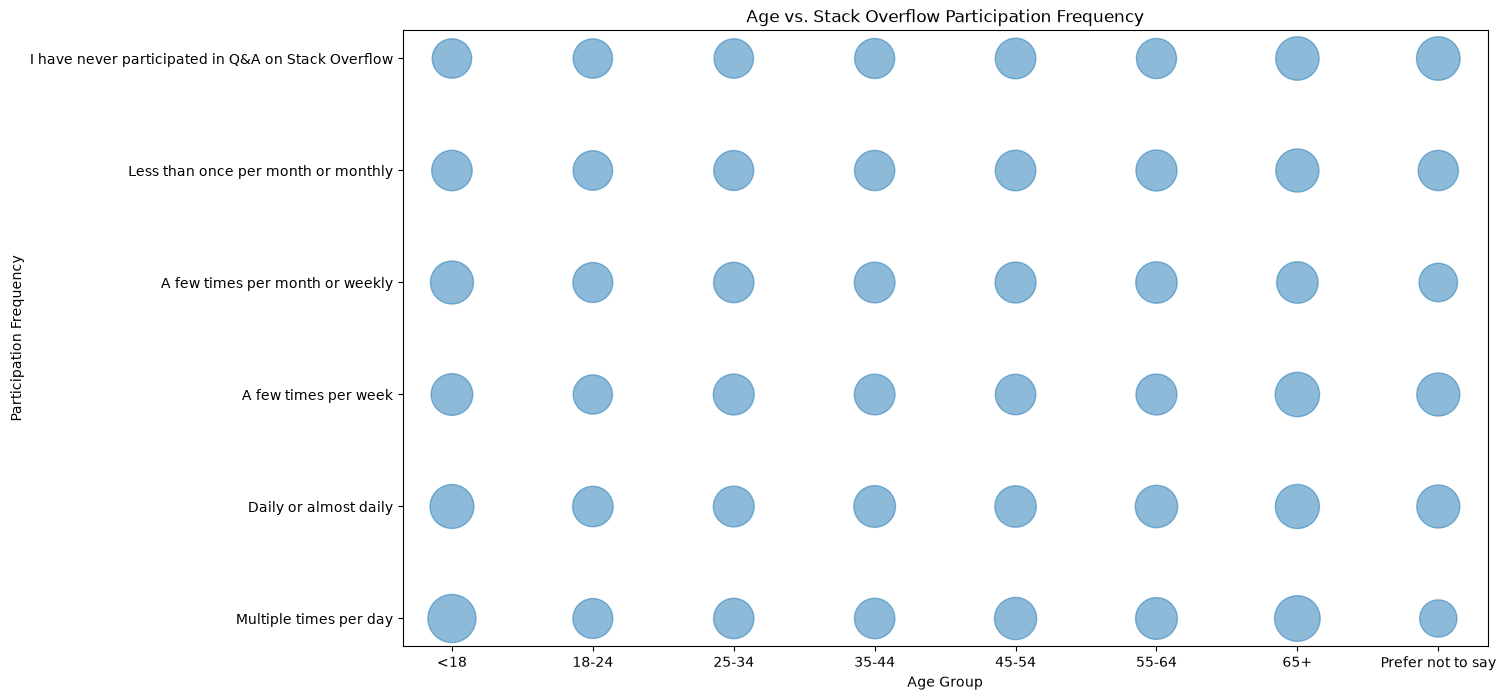

In [41]:
# Visualizing our bubleplot
import matplotlib.pyplot as plt
import numpy as np

# Remove categories that weren't included in our mappings
bubble_stats = bubble_stats.dropna(
    subset=["AgePosition", "FreqPosition"]
)

plt.figure(figsize=(14, 8))

plt.scatter(
    bubble_stats["AgePosition"],
    bubble_stats["FreqPosition"],
    s=bubble_stats["AvgJobSat"] * 120,
    alpha=0.5
)

plt.title(
    "Age vs. Stack Overflow Participation Frequency"
)

plt.xlabel("Age Group")
plt.ylabel("Participation Frequency")

plt.xticks(
    range(len(age_groups)),
    age_groups,
    rotation=0
)

plt.yticks(
    range(len(freq_groups)),
    freq_groups
)

plt.show()

#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


In [21]:
# Let's create a numerical Age column as we've done in previous assessments
age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 65
}

df["AgeNumeric"] = df["Age"].map(age_mapping)

In [22]:
# Let's prepare the dataframe for the visualization
bubble_df = df[
    ["ConvertedCompYearly", "JobSat", "AgeNumeric"]
].copy()

bubble_df["ConvertedCompYearly"] = pd.to_numeric(
    bubble_df["ConvertedCompYearly"],
    errors="coerce"
)

bubble_df["JobSat"] = pd.to_numeric(
    bubble_df["JobSat"],
    errors="coerce"
)

bubble_df = bubble_df.dropna(
    subset=[
        "ConvertedCompYearly",
        "JobSat",
        "AgeNumeric"
    ]
)

In [23]:
# Limit extreme compensation values
upper_limit = bubble_df[
    "ConvertedCompYearly"
].quantile(0.99)

bubble_plot = bubble_df[
    bubble_df["ConvertedCompYearly"] <= upper_limit
].copy()

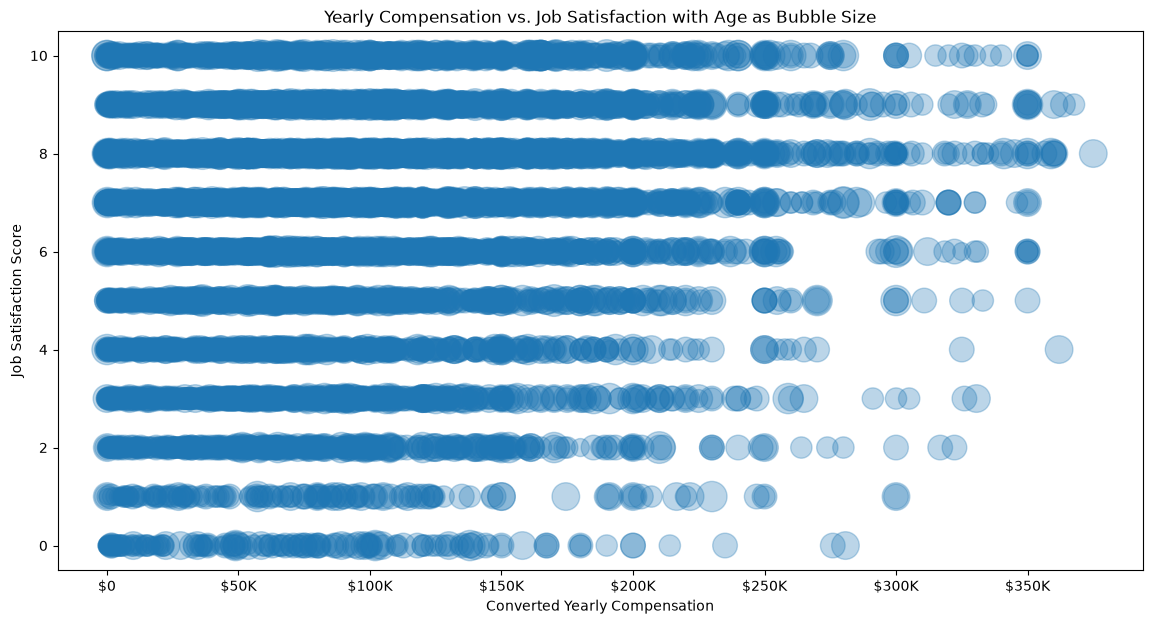

In [26]:
# Visualize the bubluplot
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def currency_formatter(x, pos):
    if x >= 1_000_000:
        return f"${x/1_000_000:.0f}M"
    elif x >= 1_000:
        return f"${x/1_000:.0f}K"
    else:
        return f"${x:.0f}"

plt.figure(figsize=(14, 7))

plt.scatter(
    bubble_plot["ConvertedCompYearly"],
    bubble_plot["JobSat"],
    s=bubble_plot["AgeNumeric"] * 8,
    alpha=0.3
)

plt.title(
    "Yearly Compensation vs. Job Satisfaction "
    "with Age as Bubble Size"
)

plt.xlabel("Converted Yearly Compensation")
plt.ylabel("Job Satisfaction Score")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.show()

### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



In [42]:
# Let's prepare the data
bubble_df = df[
    ["Age", "LanguageHaveWorkedWith"]
].copy()

bubble_df = bubble_df.dropna(
    subset=["Age", "LanguageHaveWorkedWith"]
)

In [43]:
# And split the program languages in nindividual reecords
bubble_df["Language"] = (
    bubble_df["LanguageHaveWorkedWith"]
    .str.split(";")
)

bubble_df = bubble_df.explode("Language")

bubble_df["Language"] = (
    bubble_df["Language"]
    .str.strip()
)

In [44]:
# Find the top 10 for better visualization
top_languages = (
    bubble_df["Language"]
    .value_counts()
    .head(10)
    .index
    .tolist()
)

top_languages

['JavaScript',
 'HTML/CSS',
 'Python',
 'SQL',
 'TypeScript',
 'Bash/Shell (all shells)',
 'Java',
 'C#',
 'C++',
 'C']

In [45]:
# filter our dataframe for those languages
bubble_df = bubble_df[
    bubble_df["Language"].isin(top_languages)
]

In [46]:
# An generate a stats dataframe count lanagues by age group
language_stats = (
    bubble_df
    .groupby(["Age", "Language"])
    .size()
    .reset_index(name="Frequency")
)

language_stats.head(15)

,Age,Language,Frequency
0,18-24,Bash/Shell (all shells),4069
1,18-24,C,4309
2,18-24,C#,3442
3,18-24,C++,4543
4,18-24,HTML/CSS,7724
5,18-24,Java,5038
6,18-24,JavaScript,8518
7,18-24,Python,7868
8,18-24,SQL,6257
9,18-24,TypeScript,5128


In [48]:
# Let's define Age order groups for the visualization
age_groups = [
    "<18",
    "18-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65+"
]

In [49]:
# Create numeric positions
age_positions = {
    age: i
    for i, age in enumerate(age_groups)
}

language_positions = {
    language: i
    for i, language in enumerate(top_languages)
}

language_stats["AgePosition"] = (
    language_stats["Age"].map(age_positions)
)

language_stats["LanguagePosition"] = (
    language_stats["Language"].map(language_positions)
)

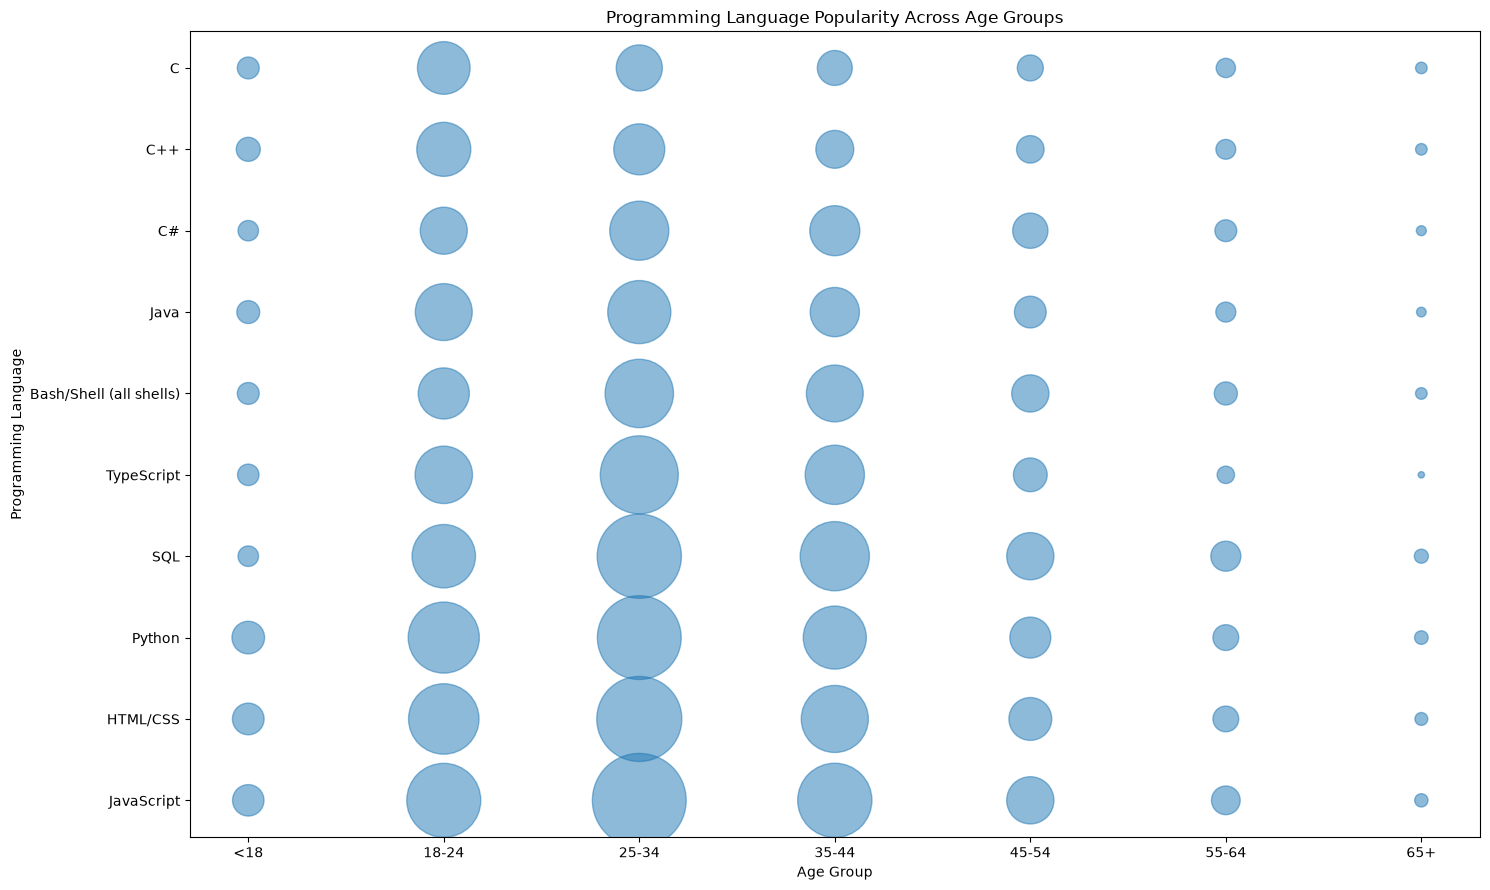

In [50]:
# And create our bubleplot
plt.figure(figsize=(15, 9))

plt.scatter(
    language_stats["AgePosition"],
    language_stats["LanguagePosition"],
    s=language_stats["Frequency"] / 3,
    alpha=0.5
)

plt.title(
    "Programming Language Popularity Across Age Groups"
)

plt.xlabel("Age Group")
plt.ylabel("Programming Language")

plt.xticks(
    range(len(age_groups)),
    age_groups
)

plt.yticks(
    range(len(top_languages)),
    top_languages
)

plt.tight_layout()

plt.show()

#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


In [51]:
# Preparing the data
bubble_df = df[
    ["DatabaseWantToWorkWith", "JobSat"]
].copy()

bubble_df["JobSat"] = pd.to_numeric(
    bubble_df["JobSat"],
    errors="coerce"
)

bubble_df = bubble_df.dropna(
    subset=["DatabaseWantToWorkWith", "JobSat"]
)

In [52]:
# Split the databse selections
bubble_df["Database"] = (
    bubble_df["DatabaseWantToWorkWith"]
    .str.split(";")
)

bubble_df = bubble_df.explode("Database")

bubble_df["Database"] = (
    bubble_df["Database"]
    .str.strip()
)

In [54]:
# Find the top 10 databases
top_databases = (
    bubble_df["Database"]
    .value_counts()
    .head(10)
    .index
    .tolist()
)

top_databases

['PostgreSQL',
 'SQLite',
 'Redis',
 'MySQL',
 'MongoDB',
 'Microsoft SQL Server',
 'Elasticsearch',
 'MariaDB',
 'Dynamodb',
 'BigQuery']

In [56]:
# Calculate frequency and average satisfaction
database_stats = (
    bubble_df
    .groupby("Database")
    .agg(
        Respondents=("Database", "size"),
        AvgJobSat=("JobSat", "mean")
    )
    .reset_index()
)

database_stats.sort_values(
    "Respondents",
    ascending=False
)

,Database,Respondents,AvgJobSat
26,PostgreSQL,13261,6.941633
30,SQLite,6859,6.923458
29,Redis,6436,6.976072
23,MySQL,5973,6.982421
22,MongoDB,5655,6.903802
21,Microsoft SQL Server,4615,7.065005
12,Elasticsearch,3873,6.995094
19,MariaDB,3101,6.989681
11,Dynamodb,2150,7.083256
0,BigQuery,1423,6.947997


In [57]:
# Because databases are categorical, we'll give each database a numeric position on the X-axis
database_stats["DatabasePosition"] = range(
    len(database_stats)
)

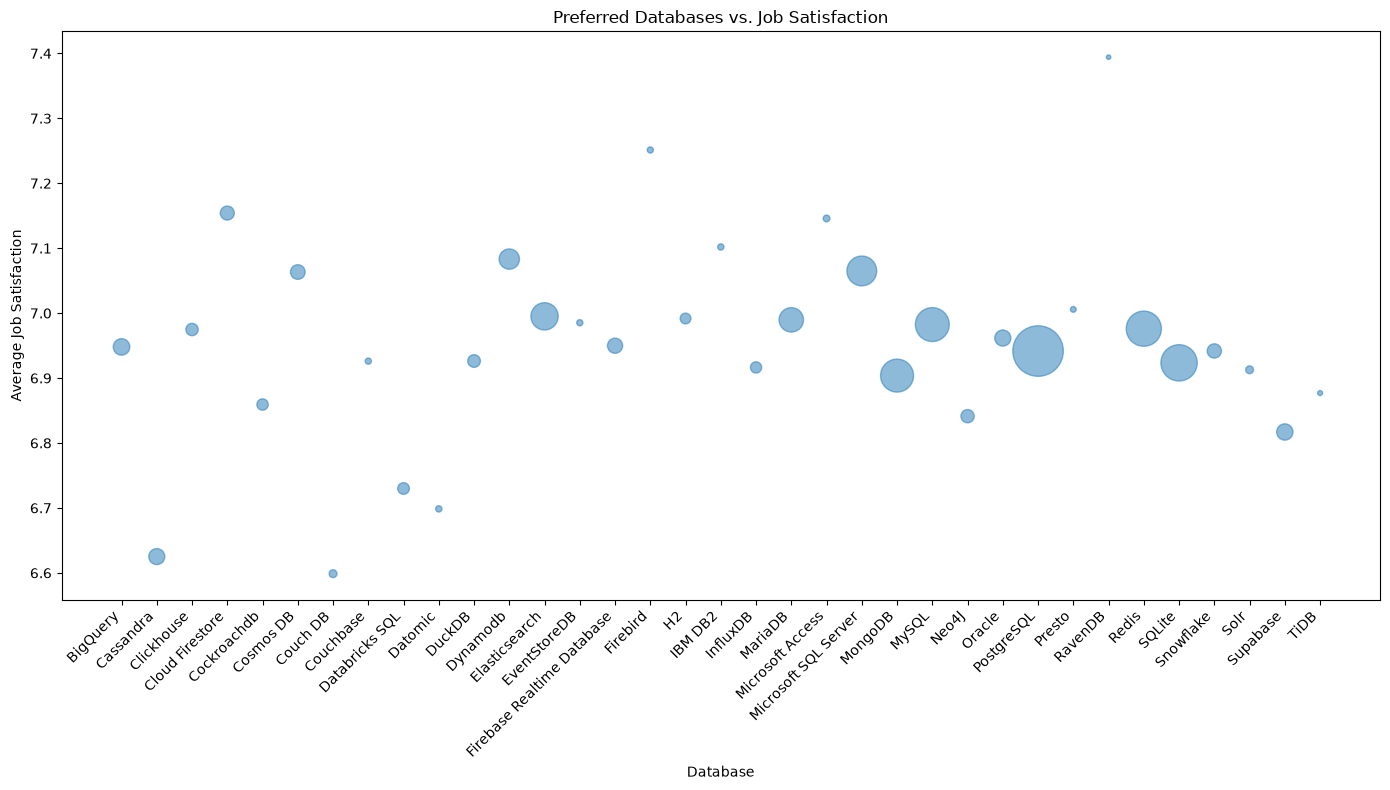

In [58]:
# Bubleplot
plt.figure(figsize=(14, 8))

plt.scatter(
    database_stats["DatabasePosition"],
    database_stats["AvgJobSat"],
    s=database_stats["Respondents"] / 10,
    alpha=0.5
)

plt.title(
    "Preferred Databases vs. Job Satisfaction"
)

plt.xlabel("Database")
plt.ylabel("Average Job Satisfaction")

plt.xticks(
    database_stats["DatabasePosition"],
    database_stats["Database"],
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


In [59]:
# Preparing the dataframe
bubble_df = df[
    ["DevType", "ConvertedCompYearly", "JobSat"]
].copy()

bubble_df["ConvertedCompYearly"] = pd.to_numeric(
    bubble_df["ConvertedCompYearly"],
    errors="coerce"
)

bubble_df["JobSat"] = pd.to_numeric(
    bubble_df["JobSat"],
    errors="coerce"
)

bubble_df = bubble_df.dropna(
    subset=[
        "DevType",
        "ConvertedCompYearly",
        "JobSat"
    ]
)

In [60]:
# Split the developers roles
bubble_df["DeveloperRole"] = (
    bubble_df["DevType"]
    .str.split(";")
)

bubble_df = bubble_df.explode(
    "DeveloperRole"
)

bubble_df["DeveloperRole"] = (
    bubble_df["DeveloperRole"]
    .str.strip()
)

In [61]:
# Finding the top 10 developers roles
top_roles = (
    bubble_df["DeveloperRole"]
    .value_counts()
    .head(10)
)

top_roles

DeveloperRole
Developer, full-stack                            5792
Developer, back-end                              3419
Developer, front-end                              924
Developer, desktop or enterprise applications     705
Developer, mobile                                 573
Developer, embedded applications or devices       511
Other (please specify):                           420
Engineering manager                               416
Data engineer                                     394
DevOps specialist                                 334
Name: count, dtype: int64

In [62]:
# Filtering the dataframe based on the top 10 roles
bubble_df = bubble_df[
    bubble_df["DeveloperRole"].isin(
        top_roles.index
    )
]

In [64]:
# Calculating compensation and satisfaction
role_stats = (
    bubble_df
    .groupby("DeveloperRole")
    .agg(
        AvgCompensation=("ConvertedCompYearly", "mean"),
        AvgJobSat=("JobSat", "mean"),
        Respondents=("DeveloperRole", "size")
    )
    .reset_index()
)

role_stats.sort_values(
    "AvgCompensation",
    ascending=False
)

,DeveloperRole,AvgCompensation,AvgJobSat,Respondents
8,Engineering manager,130082.766827,7.151442,416
9,Other (please specify):,101309.454762,7.069048,420
2,"Developer, back-end",89297.440187,6.898508,3419
4,"Developer, embedded applications or devices",89001.270059,6.843444,511
0,Data engineer,84464.885787,6.682741,394
7,"Developer, mobile",83515.212914,6.984293,573
1,DevOps specialist,82482.694611,6.931138,334
3,"Developer, desktop or enterprise applications",78007.441135,6.880851,705
6,"Developer, full-stack",74961.550414,6.902797,5792
5,"Developer, front-end",68443.510823,6.852814,924


In [65]:
# Compensation is usually heavily skewed, so the mean can be strongly affected by extreme values
# Let's imit the individual compensation observations to the 95th percentile before calculating the role averages
upper_limit = bubble_df[
    "ConvertedCompYearly"
].quantile(0.95)

bubble_df = bubble_df[
    bubble_df["ConvertedCompYearly"] <= upper_limit
]

In [66]:
# Recalculating the stats
role_stats = (
    bubble_df
    .groupby("DeveloperRole")
    .agg(
        AvgCompensation=("ConvertedCompYearly", "mean"),
        AvgJobSat=("JobSat", "mean"),
        Respondents=("DeveloperRole", "size")
    )
    .reset_index()
)

In [67]:
# Since developer roles are categorical, give them numeric positions
role_stats["RolePosition"] = range(
    len(role_stats)
)

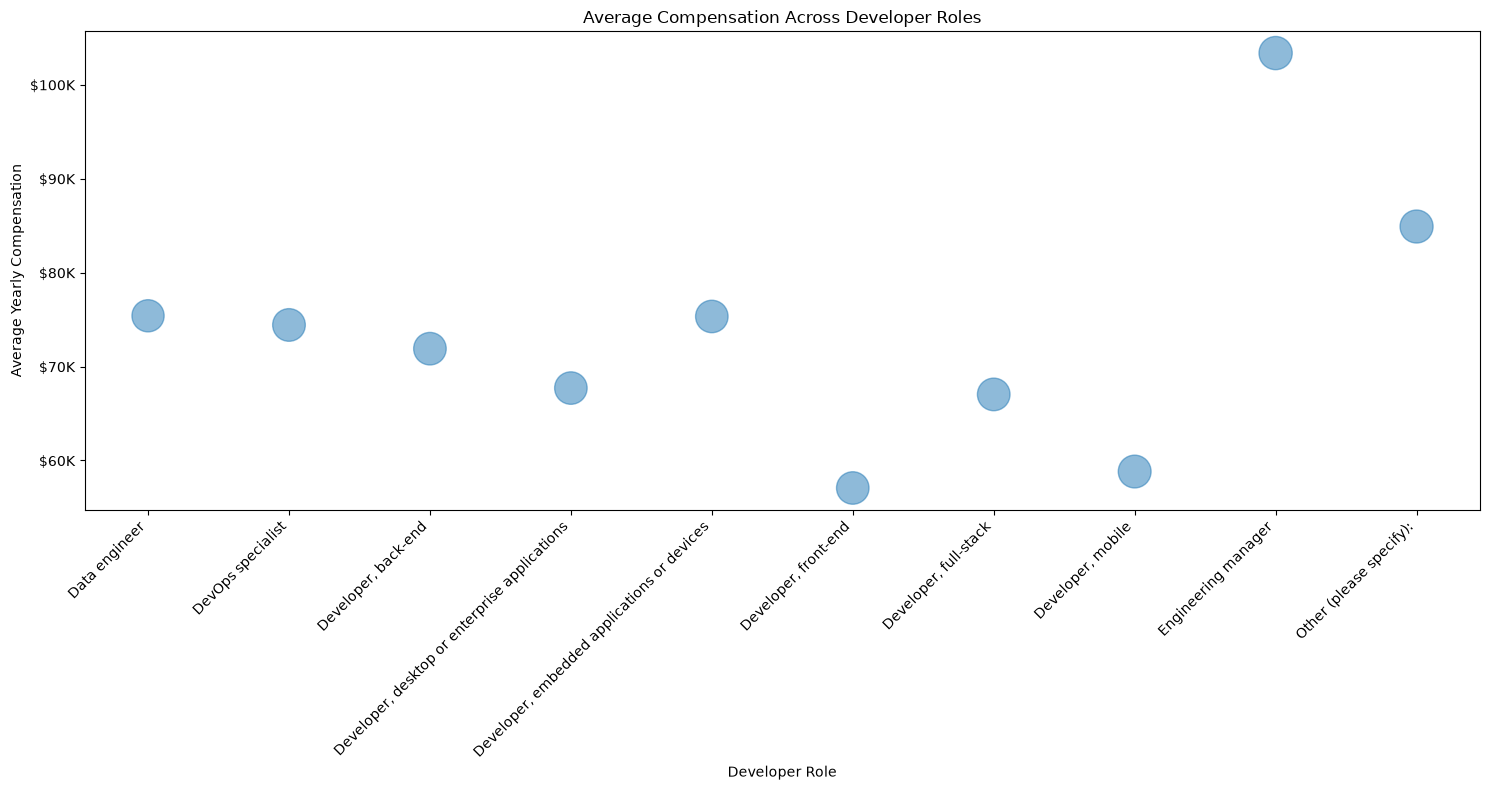

In [72]:
# Bubleplot
plt.figure(figsize=(15, 8))

plt.scatter(
    role_stats["RolePosition"],
    role_stats["AvgCompensation"],
    s=role_stats["AvgJobSat"] * 80,
    alpha=0.5
)

plt.title(
    "Average Compensation Across Developer Roles"
)

plt.xlabel("Developer Role")
plt.ylabel("Average Yearly Compensation")

plt.xticks(
    role_stats["RolePosition"],
    role_stats["DeveloperRole"],
    rotation=45,
    ha="right"
)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.tight_layout()

plt.show()

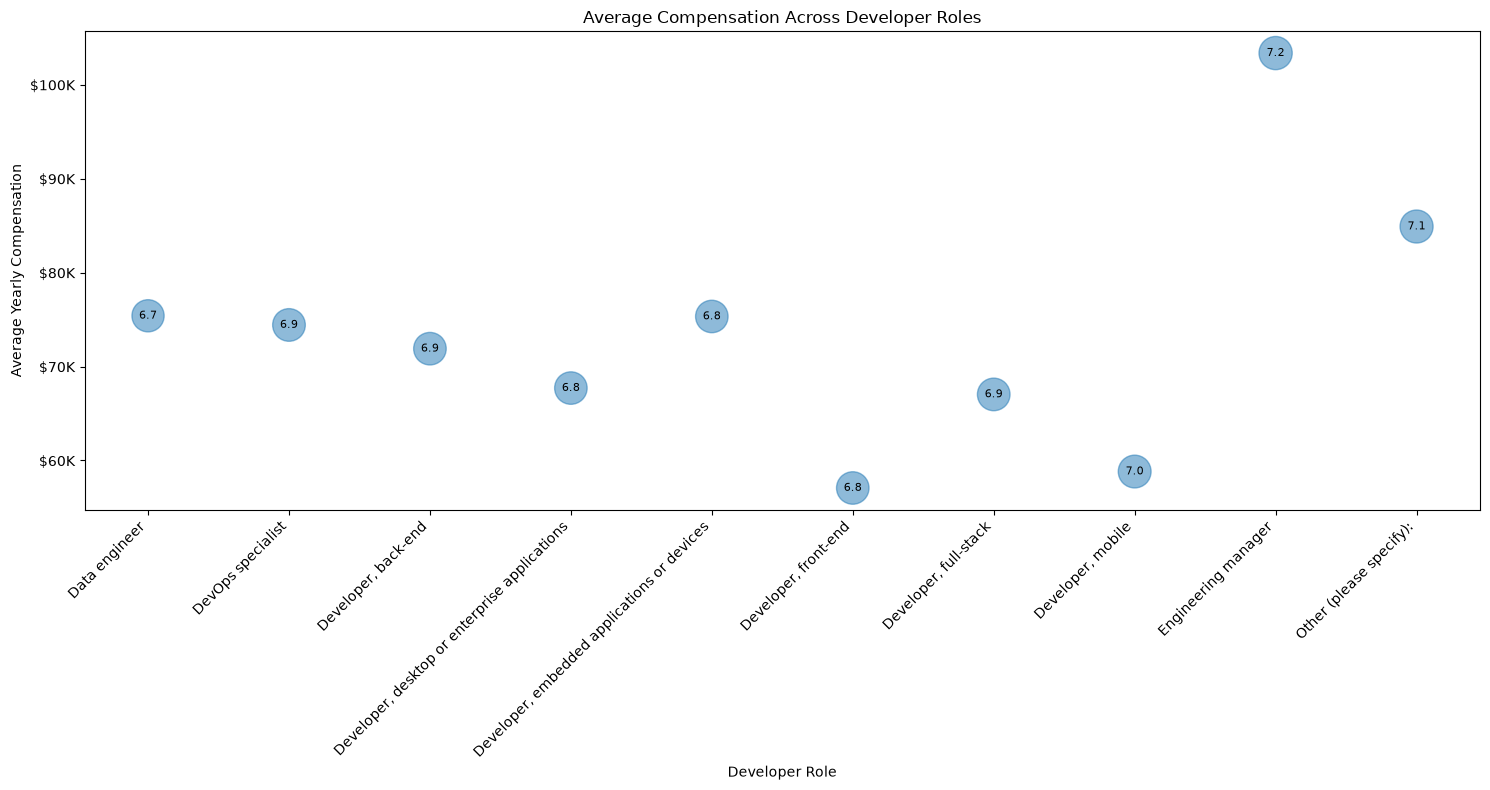

In [70]:
# We can also add satisfaction values to the bubles
plt.figure(figsize=(15, 8))

plt.scatter(
    role_stats["RolePosition"],
    role_stats["AvgCompensation"],
    s=role_stats["AvgJobSat"] * 80,
    alpha=0.5
)

for _, row in role_stats.iterrows():

    plt.annotate(
        f"{row['AvgJobSat']:.1f}",
        (
            row["RolePosition"],
            row["AvgCompensation"]
        ),
        ha="center",
        va="center",
        fontsize=8
    )

plt.title(
    "Average Compensation Across Developer Roles"
)

plt.xlabel("Developer Role")
plt.ylabel("Average Yearly Compensation")

plt.xticks(
    role_stats["RolePosition"],
    role_stats["DeveloperRole"],
    rotation=45,
    ha="right"
)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.tight_layout()

plt.show()

#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


In [73]:
# Preparing the data
bubble_df = df[
    ["Age", "NEWCollabToolsHaveWorkedWith"]
].copy()

bubble_df = bubble_df.dropna(
    subset=["Age", "NEWCollabToolsHaveWorkedWith"]
)

In [74]:
# Splitting the collaboration tools
bubble_df["CollabTool"] = (
    bubble_df["NEWCollabToolsHaveWorkedWith"]
    .str.split(";")
)

bubble_df = bubble_df.explode("CollabTool")

bubble_df["CollabTool"] = (
    bubble_df["CollabTool"]
    .str.strip()
)

In [75]:
# Fiding the most popular tools
top_tools = (
    bubble_df["CollabTool"]
    .value_counts()
    .head(10)
    .index
    .tolist()
)

top_tools

['Visual Studio Code',
 'Visual Studio',
 'IntelliJ IDEA',
 'Notepad++',
 'Vim',
 'Android Studio',
 'PyCharm',
 'Jupyter Notebook/JupyterLab',
 'Neovim',
 'Sublime Text']

In [76]:
# Filtering the data based on the top 10 most popular tools
bubble_df = bubble_df[
    bubble_df["CollabTool"].isin(top_tools)
]

In [78]:
# Counting tools usage by age group
tool_stats = (
    bubble_df
    .groupby(["Age", "CollabTool"])
    .size()
    .reset_index(name="Frequency")
)

tool_stats.head(10)

,Age,CollabTool,Frequency
0,18-24,Android Studio,2663
1,18-24,IntelliJ IDEA,3932
2,18-24,Jupyter Notebook/JupyterLab,2122
3,18-24,Neovim,2289
4,18-24,Notepad++,2368
5,18-24,PyCharm,2476
6,18-24,Sublime Text,1209
7,18-24,Vim,2471
8,18-24,Visual Studio,3838
9,18-24,Visual Studio Code,9598


In [79]:
# Defining my age groups
age_groups = [
    "<18",
    "18-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65+"
]

In [80]:
# Creating position for the axis
age_positions = {
    age: i
    for i, age in enumerate(age_groups)
}

tool_positions = {
    tool: i
    for i, tool in enumerate(top_tools)
}

tool_stats["AgePosition"] = (
    tool_stats["Age"].map(age_positions)
)

tool_stats["ToolPosition"] = (
    tool_stats["CollabTool"].map(tool_positions)
)

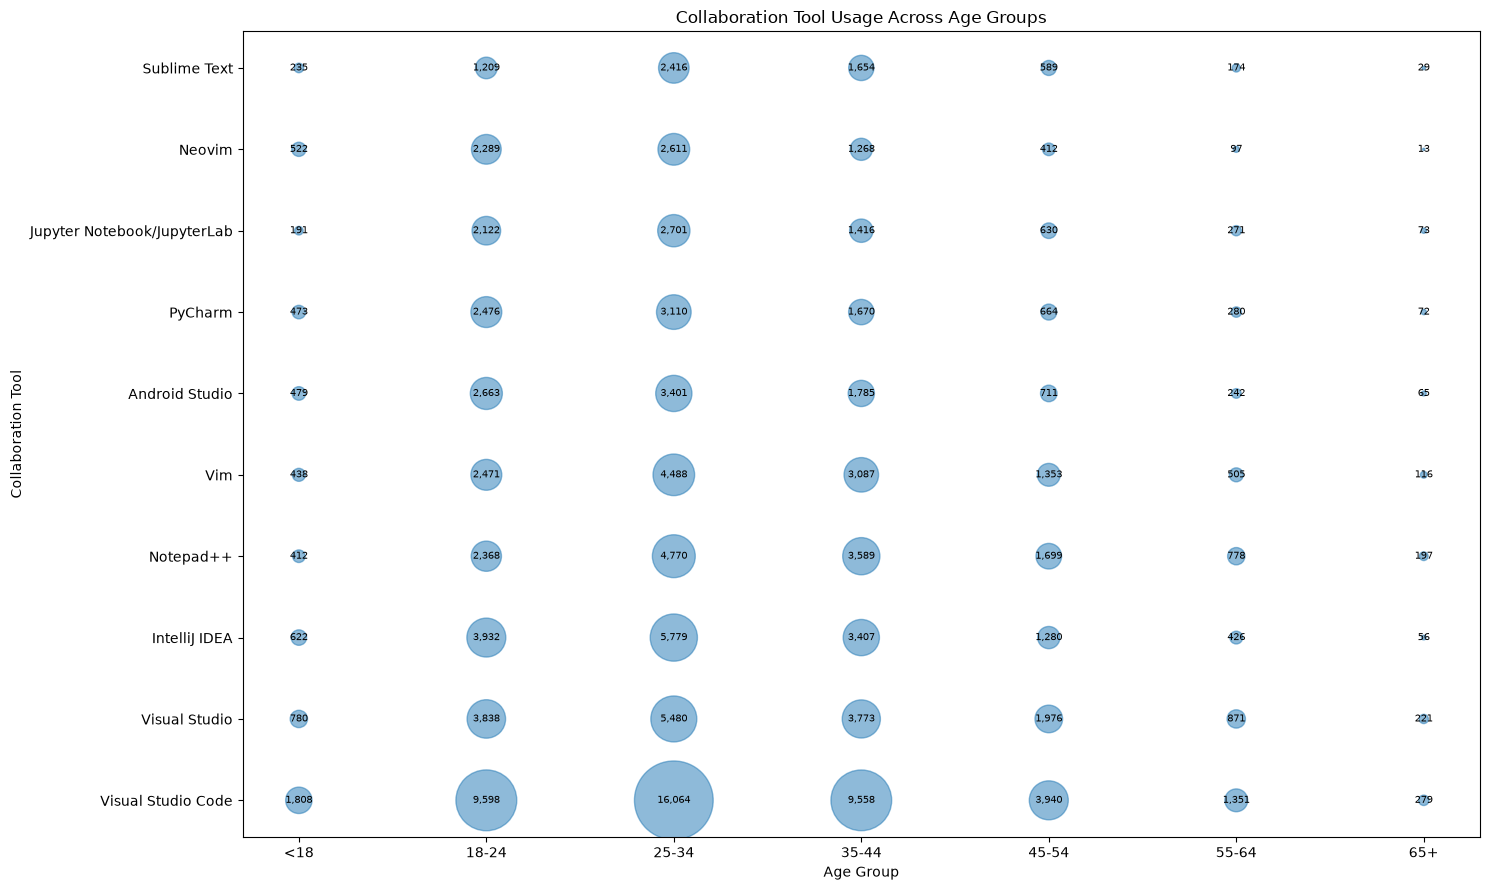

In [81]:
# Creating bublplot with labels
plt.figure(figsize=(15, 9))

plt.scatter(
    tool_stats["AgePosition"],
    tool_stats["ToolPosition"],
    s=tool_stats["Frequency"] / 5,
    alpha=0.5
)

for _, row in tool_stats.iterrows():
    plt.annotate(
        f"{row['Frequency']:,}",
        (
            row["AgePosition"],
            row["ToolPosition"]
        ),
        ha="center",
        va="center",
        fontsize=7
    )

plt.title(
    "Collaboration Tool Usage Across Age Groups"
)

plt.xlabel("Age Group")
plt.ylabel("Collaboration Tool")

plt.xticks(
    range(len(age_groups)),
    age_groups
)

plt.yticks(
    range(len(top_tools)),
    top_tools
)

plt.tight_layout()

plt.show()

### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



In [82]:
# Preparing the data
bubble_df = df[
    ["WebframeWantToWorkWith", "JobSat"]
].copy()

bubble_df["JobSat"] = pd.to_numeric(
    bubble_df["JobSat"],
    errors="coerce"
)

bubble_df = bubble_df.dropna(
    subset=["WebframeWantToWorkWith", "JobSat"]
)

In [83]:
# Splitting the frameworks
bubble_df["WebFramework"] = (
    bubble_df["WebframeWantToWorkWith"]
    .str.split(";")
)

bubble_df = bubble_df.explode(
    "WebFramework"
)

bubble_df["WebFramework"] = (
    bubble_df["WebFramework"]
    .str.strip()
)

In [84]:
# Finding the top 10 frameworks
top_frameworks = (
    bubble_df["WebFramework"]
    .value_counts()
    .head(10)
    .index
    .tolist()
)

top_frameworks

['React',
 'Node.js',
 'Next.js',
 'ASP.NET CORE',
 'Vue.js',
 'Angular',
 'Spring Boot',
 'Express',
 'FastAPI',
 'Svelte']

In [85]:
# Filtering our dataframe based on top 10 frameworks
bubble_df = bubble_df[
    bubble_df["WebFramework"].isin(top_frameworks)
]

In [87]:
# Calculating frequency and average satisfaction
framework_stats = (
    bubble_df
    .groupby("WebFramework")
    .agg(
        Respondents=("WebFramework", "size"),
        AvgJobSat=("JobSat", "mean")
    )
    .reset_index()
)

framework_stats.sort_values(
    "Respondents",
    ascending=False
)

,WebFramework,Respondents,AvgJobSat
6,React,8167,6.951880
5,Node.js,7636,7.013227
4,Next.js,4322,6.909070
0,ASP.NET CORE,4199,7.049059
9,Vue.js,4061,6.924895
1,Angular,3541,7.009602
7,Spring Boot,2940,6.890136
2,Express,2855,6.881961
3,FastAPI,2731,6.820212
8,Svelte,2710,6.791144


In [88]:
# Creating positions for the framework
framework_stats["FrameworkPosition"] = range(
    len(framework_stats)
)

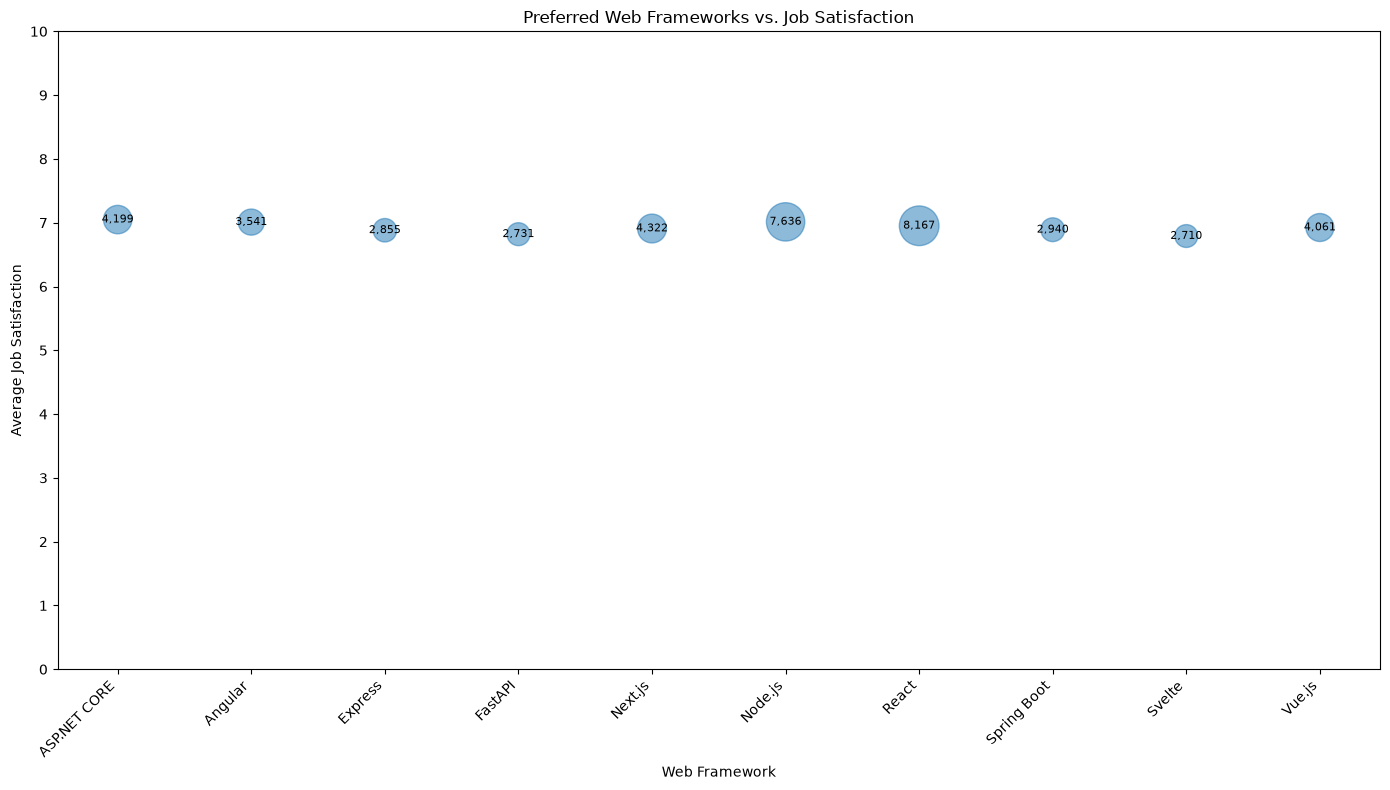

In [89]:
# Bubleplot 
plt.figure(figsize=(14, 8))

plt.scatter(
    framework_stats["FrameworkPosition"],
    framework_stats["AvgJobSat"],
    s=framework_stats["Respondents"] / 10,
    alpha=0.5
)

for _, row in framework_stats.iterrows():
    plt.annotate(
        f"{row['Respondents']:,}",
        (
            row["FrameworkPosition"],
            row["AvgJobSat"]
        ),
        ha="center",
        va="center",
        fontsize=8
    )

plt.title(
    "Preferred Web Frameworks vs. Job Satisfaction"
)

plt.xlabel("Web Framework")
plt.ylabel("Average Job Satisfaction")

plt.xticks(
    framework_stats["FrameworkPosition"],
    framework_stats["WebFramework"],
    rotation=45,
    ha="right"
)

plt.yticks(range(0, 11))

plt.tight_layout()

plt.show()

#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



In [90]:
# Preparing the data
bubble_df = df[
    ["Country", "LanguageAdmired"]
].copy()

bubble_df = bubble_df.dropna(
    subset=["Country", "LanguageAdmired"]
)

In [91]:
# Split admired languages
bubble_df["Language"] = (
    bubble_df["LanguageAdmired"]
    .str.split(";")
)

bubble_df = bubble_df.explode("Language")

bubble_df["Language"] = (
    bubble_df["Language"]
    .str.strip()
)

In [92]:
# Find the top 10 countries
top_countries = (
    bubble_df["Country"]
    .value_counts()
    .head(10)
    .index
    .tolist()
)

top_countries

['United States of America',
 'Germany',
 'India',
 'United Kingdom of Great Britain and Northern Ireland',
 'France',
 'Canada',
 'Ukraine',
 'Netherlands',
 'Poland',
 'Brazil']

In [93]:
# Filtering by the top 10 countries
bubble_df = bubble_df[
    bubble_df["Country"].isin(top_countries)
]

In [94]:
# Finding top 10 admired languages
top_languages = (
    bubble_df["Language"]
    .value_counts()
    .head(10)
    .index
    .tolist()
)

top_languages

['Python',
 'JavaScript',
 'SQL',
 'HTML/CSS',
 'TypeScript',
 'Bash/Shell (all shells)',
 'C#',
 'Java',
 'C++',
 'Rust']

In [95]:
# Let's filter again by the languages
bubble_df = bubble_df[
    bubble_df["Language"].isin(top_languages)
]

In [96]:
# Calculate the frequency
language_stats = (
    bubble_df
    .groupby(["Country", "Language"])
    .size()
    .reset_index(name="Frequency")
)

In [97]:
# Create categorical positions
country_positions = {
    country: i
    for i, country in enumerate(top_countries)
}

language_positions = {
    language: i
    for i, language in enumerate(top_languages)
}

language_stats["CountryPosition"] = (
    language_stats["Country"].map(country_positions)
)

language_stats["LanguagePosition"] = (
    language_stats["Language"].map(language_positions)
)

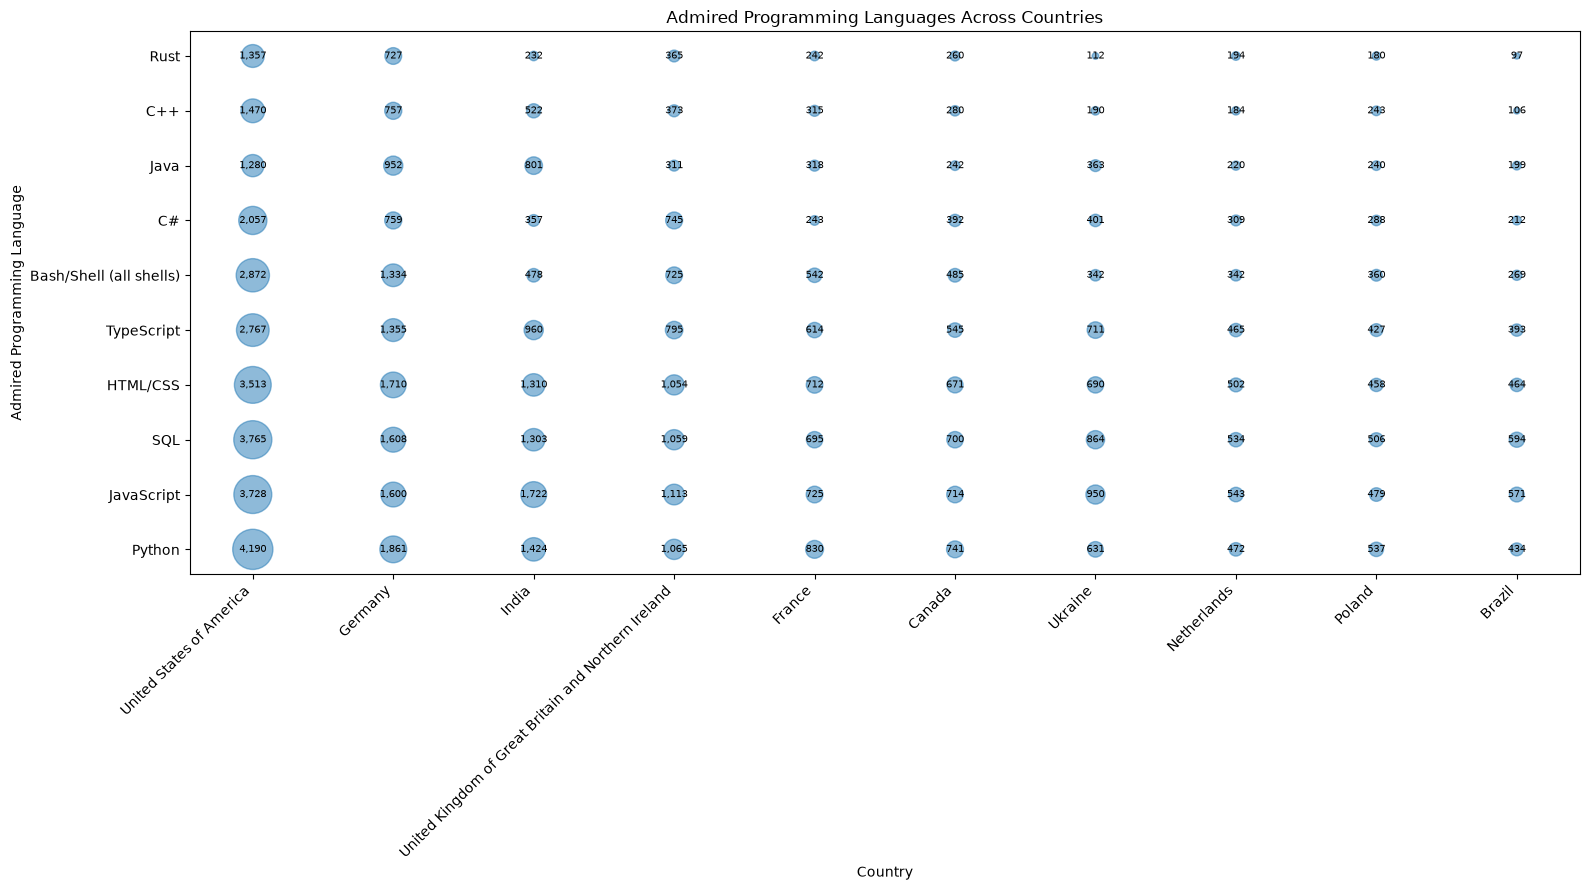

In [98]:
# Visualize our bubleplot
plt.figure(figsize=(16, 9))

plt.scatter(
    language_stats["CountryPosition"],
    language_stats["LanguagePosition"],
    s=language_stats["Frequency"] / 5,
    alpha=0.5
)

for _, row in language_stats.iterrows():
    plt.annotate(
        f"{row['Frequency']:,}",
        (
            row["CountryPosition"],
            row["LanguagePosition"]
        ),
        ha="center",
        va="center",
        fontsize=7
    )

plt.title(
    "Admired Programming Languages Across Countries"
)

plt.xlabel("Country")
plt.ylabel("Admired Programming Language")

plt.xticks(
    range(len(top_countries)),
    top_countries,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(top_languages)),
    top_languages
)

plt.tight_layout()

plt.show()

## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
